In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

#Import the Dataset
df= pd.read_csv("../dataset/english_osint_dataset.csv")
df= df.drop(columns=['latency','scan_duration'])
display(df.head(20))


,email_text,hostname,host_up,alternate_ip_count,ip_address,common_web_ports_open,open_ports_count,filtered_ports_count,open_ports,rdns_record,https_supported,services,host_found,interesting_url,asn_found,ip_found,email_type
0,Hello I am your hot lil horny toy.\n I am t...,www.mail.com,1,0,82.165.229.59,1,3,996,"80, 443, 443, 8008, 80, 8008, 443, 80, 8008",NaN,1,"https, http, https, http, https, http",0,0,0,0,Phishing Email
1,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",NaN,0,0,NaN,0,0,0,NaN,NaN,0,NaN,0,0,0,0,Safe Email
2,"URL: http://www.newsisfree.com/click/-5,830431...",www.newsisfree.com,1,1,104.21.22.148,1,5,994,"80, 8008, 80, 8443, 8080, 8008, 443, 8080, 844...",NaN,1,"https-alt, http-proxy, https, http, https-alt,...",0,0,0,0,Safe Email
3,"begin forwarded text Date: Wed, 25 Sep 2002 13...","www.ceert.org, www.ceert.org, www.ceert.org, w...",1,0,"72.167.68.110, 72.167.68.110, 192.0.66.2, 192....",1,"11, 11, 3, 11, 3, 3","982, 996, 982, 996, 996, 982","80, 995, 110, 22, 21, 587, 993, 80, 443, 993, ...","110.68.167.72.host.secureserver.net, , 110.68....",1,"submission, http, ftp, pop3s, mysql, imaps, im...",0,0,0,0,Safe Email
4,The academic discipline of Software Engineerin...,www.cs.ncl.ac.uk,1,0,128.240.208.85,1,3,996,"80, 443, 443, 8008, 80, 8008, 443, 80, 8008",apps-extweb-l.ncl.ac.uk,1,"https, http, https, http, https, http",0,0,0,0,Safe Email
5,"EFFector Vol. 15, No. 35 November ...","news.com.com, www.eff.org, www.lawsnet.com, ww...","1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1...","2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 3, 0, 0...","172.67.72.218, 151.101.0.201, 34.105.168.53, 1...","1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1...","5, 3, 1, 0, 5, 3, 3, 3, 3, 3, 3, 3, 0, 3, 1, 3...","994, 996, 996, 996, 0, 0, 994, 996, 996, 998, ...","80, 80, 443, 8008, 80, 443, 8008, 443, 8008, 4...",a23-49-226-94.deploy.static.akamaitechnologies...,"1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1...","https-alt, http, https, http, http-proxy, http...",0,0,0,0,Safe Email
6,Question?Do you want a different job?\nDo you ...,NaN,0,0,NaN,0,0,0,NaN,NaN,0,NaN,0,0,0,0,Phishing Email
7,URL: http://www.livejournal.com/talkread.bml?j...,www.livejournal.com,1,1,81.19.74.1,1,3,0,"80, 443, 443, 8008, 80, 8008, 443, 80, 8008",livejournal.com,1,"https, http, https, http, https, http",0,0,0,0,Safe Email
8,Thanks Brent: now it's clearer (to me) what's ...,NaN,0,0,NaN,0,0,0,NaN,NaN,0,NaN,0,0,0,0,Safe Email
9,Help wanted. We are a 14 year old fortune 500...,www.basetel.com,1,11,96.126.123.244,1,3,996,"80, 443, 443, 8008, 80, 8008, 443, 80, 8008",li372-244.members.linode.com,1,"https, http, https, http, https, http",0,0,0,0,Phishing Email


In [109]:
int_keys = ["ip_found","host_found","interesting_url","asn_found","ip_found",
            "host_up","alternate_ip_count","common_web_ports_open","filtered_ports_count",
            "https_supported","open_ports_count"]
for itm in int_keys:
    df[itm].fillna(0,inplace = True) 

string_keys=["hostname","ip_address","services","open_ports","rdns_record"]
for itm in string_keys:
    df[itm].fillna('',inplace = True)

C:\Users\Rana Shafi\AppData\Local\Temp\ipykernel_22160\1492188865.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[itm].fillna(0,inplace = True)
C:\Users\Rana Shafi\AppData\Local\Temp\ipykernel_22160\1492188865.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [110]:
#Check for missing values¶
df.isnull().sum()

email_text               0
hostname                 0
host_up                  0
alternate_ip_count       0
ip_address               0
common_web_ports_open    0
open_ports_count         0
filtered_ports_count     0
open_ports               0
rdns_record              0
https_supported          0
services                 0
host_found               0
interesting_url          0
asn_found                0
ip_found                 0
email_type               0
dtype: int64

In [111]:
# Handle integer columns
int_keys = [
    "ip_found", "host_found", "interesting_url", "asn_found", "host_up",
    "alternate_ip_count", "common_web_ports_open", "filtered_ports_count",
    "https_supported", "open_ports_count"
]
for itm in int_keys:
    # Convert to numeric, coerce errors, and fill NaN with 0 before converting to int
    df[itm] = pd.to_numeric(df[itm], errors="coerce").fillna(0).astype("int")


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   email_text             1002 non-null   object
 1   hostname               1002 non-null   object
 2   host_up                1002 non-null   int64 
 3   alternate_ip_count     1002 non-null   int64 
 4   ip_address             1002 non-null   object
 5   common_web_ports_open  1002 non-null   int64 
 6   open_ports_count       1002 non-null   int64 
 7   filtered_ports_count   1002 non-null   int64 
 8   open_ports             1002 non-null   object
 9   rdns_record            1002 non-null   object
 10  https_supported        1002 non-null   int64 
 11  services               1002 non-null   object
 12  host_found             1002 non-null   int64 
 13  interesting_url        1002 non-null   int64 
 14  asn_found              1002 non-null   int64 
 15  ip_found             

In [113]:
# Check for duplicate values¶
display(df)

,email_text,hostname,host_up,alternate_ip_count,ip_address,common_web_ports_open,open_ports_count,filtered_ports_count,open_ports,rdns_record,https_supported,services,host_found,interesting_url,asn_found,ip_found,email_type
0,Hello I am your hot lil horny toy.\n I am t...,www.mail.com,1,0,82.165.229.59,1,3,996,"80, 443, 443, 8008, 80, 8008, 443, 80, 8008",,1,"https, http, https, http, https, http",0,0,0,0,Phishing Email
1,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",,0,0,,0,0,0,,,0,,0,0,0,0,Safe Email
2,"URL: http://www.newsisfree.com/click/-5,830431...",www.newsisfree.com,1,1,104.21.22.148,1,5,994,"80, 8008, 80, 8443, 8080, 8008, 443, 8080, 844...",,1,"https-alt, http-proxy, https, http, https-alt,...",0,0,0,0,Safe Email
3,"begin forwarded text Date: Wed, 25 Sep 2002 13...","www.ceert.org, www.ceert.org, www.ceert.org, w...",1,0,"72.167.68.110, 72.167.68.110, 192.0.66.2, 192....",1,0,0,"80, 995, 110, 22, 21, 587, 993, 80, 443, 993, ...","110.68.167.72.host.secureserver.net, , 110.68....",1,"submission, http, ftp, pop3s, mysql, imaps, im...",0,0,0,0,Safe Email
4,The academic discipline of Software Engineerin...,www.cs.ncl.ac.uk,1,0,128.240.208.85,1,3,996,"80, 443, 443, 8008, 80, 8008, 443, 80, 8008",apps-extweb-l.ncl.ac.uk,1,"https, http, https, http, https, http",0,0,0,0,Safe Email
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,URL: http://boingboing.net/#85488621\nDate: No...,"www.craphound.com, www.barbiebazaar.com, boing...",1,0,"172.67.22.113, 3.168.236.25, 76.223.54.146, 14...",0,0,0,"80, 443, 80, 443, 8008, 80, 8008, 8080, 443, 8...","static.168.196.132.142.clients.your-server.de,...",0,"http, https, https, https-alt, https, http, ht...",0,0,0,0,Safe Email
998,"This is my first time running Razor, heard a l...","www.inphonic.com, lists.sourceforge.net",1,0,"204.235.124.180, 216.105.38.7",0,1,998,8008,", inphonic.com",0,http,0,0,0,0,Safe Email
999,"URL: http://www.newsisfree.com/click/-0,861367...",www.newsisfree.com,1,1,104.21.22.148,1,5,994,"80, 8008, 8080, 443, 8443",,1,"https-alt, https, http, http-proxy",0,0,0,6,Safe Email
1000,Chris said:\n> \n> I can tell you what the 'cl...,,0,0,,0,0,0,,,0,,0,21,2,26,Safe Email


In [114]:
# # Count the occurrences of each E-mail type. 
email_type_counts = df['email_type'].value_counts()
print(email_type_counts)

email_type
Safe Email        822
Phishing Email    180
Name: count, dtype: int64


In [115]:
#dataset shape
df.shape

(1002, 17)

In [116]:
# # We will use undersapling technique 
Safe_Email = df[df["email_type"]== "Safe Email"]
Phishing_Email = df[df["email_type"]== "Phishing Email"]
Safe_Email = Safe_Email.sample(Phishing_Email.shape[0])

In [117]:
# lets check the sahpe again 
Safe_Email.shape,Phishing_Email.shape

((180, 17), (180, 17))

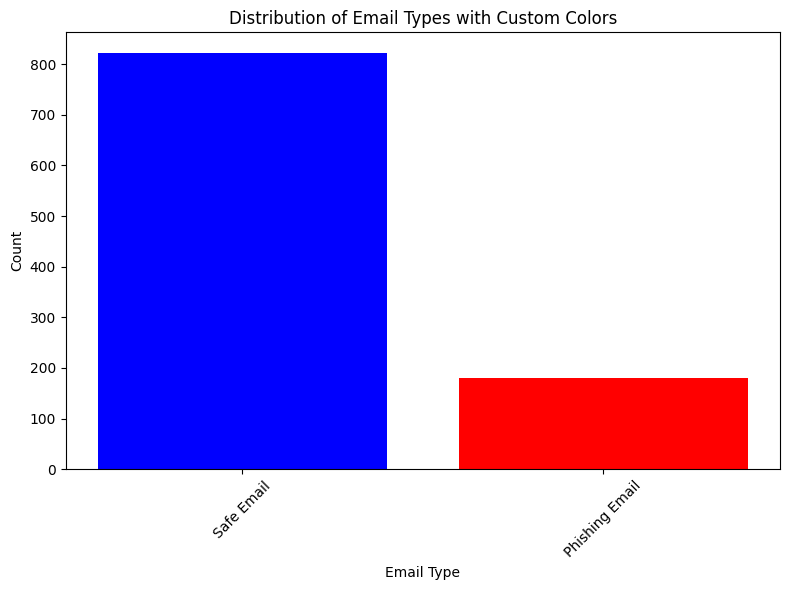

In [118]:
# Create the bar chart
# Create a list of unique email types
unique_email_types = email_type_counts.index.tolist()

# Define a custom color map 
color_map = {
    'Phishing Email': 'red',
    'Safe Email': 'blue',}

# Map the colors to each email type
colors = [color_map.get(email_type, 'gray') for email_type in unique_email_types]

# Create the bar chart with custom colors
plt.figure(figsize=(8, 6))
plt.bar(unique_email_types, email_type_counts, color=colors)
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.title('Distribution of Email Types with Custom Colors')
plt.xticks(rotation=45)

# Show the chart
plt.tight_layout()
plt.show()

In [119]:
# lest create a new Data with the balanced E-mail types
Data= pd.concat([Safe_Email, Phishing_Email], ignore_index = True)
Data.head()
display(Data)

,email_text,hostname,host_up,alternate_ip_count,ip_address,common_web_ports_open,open_ports_count,filtered_ports_count,open_ports,rdns_record,https_supported,services,host_found,interesting_url,asn_found,ip_found,email_type
0,And of course I forget the link that I did fin...,www.constitutioncenter.org,1,2,104.22.22.181,1,5,994,"80, 8008, 8080, 443, 8443",,1,"https-alt, https, http, http-proxy",0,0,1,9,Safe Email
1,Because of this:\nhttp://hrw.org/press/2002/08...,hrw.org,1,0,23.185.0.2,1,3,996,"80, 443, 8008",,1,"https, http",121,0,0,304,Safe Email
2,"Elias Sinderson writes:> Sorry, Karl, your co...","www.monkey.org, xent.com",1,0,"69.55.232.243, 104.197.149.9",0,0,0,"80, 22, 443, 8008",", monkey.org",0,"https, ssh, http",0,3,0,0,Safe Email
3,"Filled with useful examples and the depth, cla...","www.oreillynet.com, www.oreilly.com",1,0,"23.52.38.113, 34.169.83.167",0,0,0,"80, 443, 8008",a23-52-38-113.deploy.static.akamaitechnologies...,0,"https, http",0,0,0,0,Safe Email
4,>Helen & Mike wrote:\n>\n>> Chat tends to be ...,", docs.yahoo.com",0,0,", 76.223.84.192",0,0,0,", 443, 80, 8008",", a7de0457831fd11f7.awsglobalaccelerator.com",0,", https, http",0,0,0,0,Safe Email
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,"Hello,This is a one time mailing. We are looki...","www.jabber.com, lists.sourceforge.net",1,0,"209.197.196.1, 216.105.38.7",0,1,998,8008,", wwwprodv-sj.webex.com",0,http,0,0,0,0,Phishing Email
356,"Dear Sir, *Â¡Â°Ã–ÃÃ‚Â·ÃÂ¨Ã…Ã¤Â¼Ã¾Â³Â§Â¡Â±Ã...",,0,0,,0,0,0,,,0,,0,0,0,0,Phishing Email
357,Professional Appointment \n SettingCommercial...,xent.com,1,0,69.55.232.243,0,1,998,8008,,0,http,11,3,1,2,Phishing Email
358,Give me 5 minutes and I will show you how\nto ...,"lists.sourceforge.net, thinkgeek.com",1,0,"3.168.236.115, 216.105.38.7",1,3,996,"80, 443, 80, 443, 8008, 8008",", server-3-168-236-115.ist50.r.cloudfront.net",1,"https, http, https, http",0,0,0,0,Phishing Email


In [120]:
# import numpy as np
# import pandas as pd
# from sklearn.naive_bayes import ComplementNB, BernoulliNB, MultinomialNB
# from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# import matplotlib.pyplot as plt
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from scipy.sparse import hstack


# # Replace labels and convert to integer
# df['email_type'] = df['email_type'].replace({'Safe Email': 0, 'Phishing Email': 1}).astype(int)

# # Define models and names
# models = [ComplementNB(), BernoulliNB(), MultinomialNB()]
# model_names = ['ComplementNB', 'BernoulliNB', 'MultinomialNB']

# accuracies = []
# precisions = []
# recalls = []
# f1 = []

# # Convert email text feature using TF-IDF
# tfidf = TfidfVectorizer()
# X_text = tfidf.fit_transform(df['email_text'])

# categorical_features = ['hostname', 'rdns_record', 'services','ip_address','open_ports']  # Features with string values
# numerical_features = [
#     'host_up', 'alternate_ip_count', 'common_web_ports_open',
#     'open_ports_count', 'filtered_ports_count', 'https_supported',
#     'host_found', 'interesting_url', 'asn_found', 'ip_found'
# ]

# # Handle missing values (fill numeric with 0, categorical with "unknown")
# df[numerical_features] = df[numerical_features].fillna(0)
# df[categorical_features] = df[categorical_features].fillna('unknown')

# # Encode categorical features using OneHotEncoder
# onehot = OneHotEncoder(handle_unknown='ignore')
# encoded_categorical = onehot.fit_transform(df[categorical_features])

# from sklearn.preprocessing import MinMaxScaler

# # Replace StandardScaler with MinMaxScaler
# scaler = MinMaxScaler()
# scaled_numerical = scaler.fit_transform(df[numerical_features])

# # Combine categorical and numerical features
# X_additional = hstack([encoded_categorical, scaled_numerical])

# tfidf = TfidfVectorizer()
# X_text = tfidf.fit_transform(df['email_text'])

# # Combine TF-IDF-transformed text and additional features
# X_combined = hstack([X_text, X_additional])

# # Define the target variable
# Y = df['email_type']


In [121]:
# import numpy as np
# import pandas as pd
# from sklearn.svm import SVC
# from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# from scipy.sparse import hstack
# import matplotlib.pyplot as plt

# # Replace labels and convert to integer
# df['email_type'] = df['email_type'].replace({'Safe Email': 0, 'Phishing Email': 1}).astype(int)

# # Define categorical and numerical features
# categorical_features = ['hostname', 'rdns_record', 'services', 'ip_address', 'open_ports']
# numerical_features = [
#     'host_up', 'alternate_ip_count', 'common_web_ports_open',
#     'open_ports_count', 'filtered_ports_count', 'https_supported',
#     'host_found', 'interesting_url', 'asn_found', 'ip_found'
# ]

# # Handle missing values
# df[numerical_features] = df[numerical_features].fillna(0)
# df[categorical_features] = df[categorical_features].fillna('unknown')

# # Encode categorical features
# onehot = OneHotEncoder(handle_unknown='ignore')
# encoded_categorical = onehot.fit_transform(df[categorical_features])

# # Scale numerical features
# scaler = MinMaxScaler()
# scaled_numerical = scaler.fit_transform(df[numerical_features])

# # Combine categorical and numerical features
# X_additional = hstack([encoded_categorical, scaled_numerical])

# # Convert email text feature using TF-IDF
# tfidf = TfidfVectorizer()
# X_text = tfidf.fit_transform(df['email_text'])

# # Combine TF-IDF-transformed text and additional features
# X_combined = hstack([X_text, X_additional])

# # Define the target variable
# Y = df['email_type']

# # Split into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_combined, Y, test_size=0.3, random_state=42)

# # Fit and transform X_train (and transform X_test)
# X_train_tfidf = tfidf.fit_transform(X_train)  # Converts text to numeric matrix
# X_test_tfidf = tfidf.transform(X_test)   # Use the same transformation on test data

# # Convert the sparse matrix to dense format (this can increase memory usage for large datasets)
# X_train_dense = X_train_tfidf.toarray()
# X_test_dense = X_test_tfidf.toarray()

# # instantiate the DecisionTreeClassifier model with criterion gini index
# clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)

# # Fit the model
# clf_gini.fit(X_train_dense, y_train)

# # Predict with the model
# y_pred_gini = clf_gini.predict(X_test_dense)
# y_pred_train_gini = clf_gini.predict(X_train_dense)

In [122]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.sparse import hstack
import matplotlib.pyplot as plt

# Replace labels and convert to integer
df['email_type'] = df['email_type'].replace({'Safe Email': 0, 'Phishing Email': 1}).astype(int)

# Define categorical and numerical features
categorical_features = ['hostname', 'rdns_record', 'services', 'ip_address', 'open_ports']
numerical_features = [
    'host_up', 'alternate_ip_count', 'common_web_ports_open',
    'open_ports_count', 'filtered_ports_count', 'https_supported',
    'host_found', 'interesting_url', 'asn_found', 'ip_found'
]

# Handle missing values
df[numerical_features] = df[numerical_features].fillna(0)
df[categorical_features] = df[categorical_features].fillna('unknown')

# Encode categorical features
onehot = OneHotEncoder(handle_unknown='ignore')
encoded_categorical = onehot.fit_transform(df[categorical_features])

# Scale numerical features
scaler = MinMaxScaler()
scaled_numerical = scaler.fit_transform(df[numerical_features])

# Convert email text feature using TF-IDF
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(df['email_text'])

# Combine TF-IDF-transformed text and additional features
X_combined = hstack([X_text, encoded_categorical, scaled_numerical])

# Define the target variable
Y = df['email_type']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, Y, test_size=0.3, random_state=42)

# Convert the sparse matrices to dense format for DecisionTreeClassifier
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Instantiate the DecisionTreeClassifier model with criterion gini index
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)

# Fit the model
clf_gini.fit(X_train_dense, y_train)

# Predict with the model
y_pred_gini = clf_gini.predict(X_test_dense)
y_pred_train_gini = clf_gini.predict(X_train_dense)

# # Evaluate the model
# accuracy = accuracy_score(y_test, y_pred_gini)
# precision = precision_score(y_test, y_pred_gini)
# recall = recall_score(y_test, y_pred_gini)
# f1 = f1_score(y_test, y_pred_gini)

# # Print evaluation metrics
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("F1 Score:", f1)


C:\Users\Rana Shafi\AppData\Local\Temp\ipykernel_22160\132739565.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['email_type'] = df['email_type'].replace({'Safe Email': 0, 'Phishing Email': 1}).astype(int)


In [123]:
# record accuracy in file
from sklearn.metrics import accuracy_score
with open("osint_dt_model_accuracy.txt", "a") as file:
    file.write(f"\n(criterion=gini)\n Training set score: {accuracy_score(y_train, y_pred_train_gini):.4f}\n Test set score:{accuracy_score(y_test, y_pred_gini):.4f}")

In [124]:
from sklearn.tree import DecisionTreeClassifier
clf_entro = DecisionTreeClassifier(criterion = 'entropy',max_depth=3, random_state = 0)
clf_entro.fit(X_train_dense, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [125]:
y_pred_entro = clf_entro.predict(X_test_dense)

In [126]:
y_pred_train_entro = clf_entro.predict(X_train_dense)

In [127]:
# record accuracy in file
with open("osint_dt_model_accuracy.txt", "a") as file:
    file.write(f"\n(criterion=entropy)\nTraining set score: {accuracy_score(y_train, y_pred_train_entro):.4f}\n Test set score:{accuracy_score(y_test, y_pred_entro):.4f}")